In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Improve chart appearance
sns.set_style("whitegrid")

In [2]:
# Load the netflix dataset
netflix = pd.read_csv("netflix_titles.csv")

# Display the first five rows
print("\n the first five rows:", netflix.head(5))

# Display last five rows
print("\n the last five rows:", netflix.tail(5))


 the first five rows:   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  Sep

In [3]:
# Number of rows and columns
print("Dataset Shape", netflix.shape)

# Display all column names
print("\n Columns Names:", netflix.columns)

# Display dataset summary
print("\n Info:", netflix.info())

# Display data type of each column
print("\n Columns:", netflix.dtypes)

Dataset Shape (8807, 12)

 Columns Names: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB

 Info: None

 Columns: show_id           str
type              st

In [4]:
# Check missing values in each column
print("Missing values:", netflix.isnull().sum())

Missing values: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
# Missing value percentage
missing_percentage = (netflix.isnull().sum() / len(netflix)) * 100
missing_percentage.sort_values(ascending = False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [6]:
# Count duplicate rows
print("Duplicate values:",netflix.duplicated().sum())

# Check of unqiue values in each cplumn
print("\n Unqiue values:", netflix.nunique())

# Summary statistics for numeric columns
print("\n Statistics values:", netflix.describe())

Duplicate values: 0

 Unqiue values: show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

 Statistics values:        release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [7]:
# Summary statistics for object columns
print("Summary for object columns:", netflix.describe(include = "object"))

Summary for object columns:        show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         1   6131                     1             19   

                      cast        country       date_added rating  duration  \
count                 7982           7976             8797   8803      8804   
unique                7692            748             1767     17       220   
top     David Attenborough  United States  January 1, 2020  TV-MA  1 Season   
freq                    19           2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dramas, International Movies   
freq                             362   

                                              description  
coun

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25496\322053076.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Summary for object columns:", netflix.describe(include = "object"))


In [8]:
# Create a copy of the original dataset
df = netflix.copy()

In [9]:
# Check duplicate rows
print(" Check Duplicate values:", df.duplicated().sum())

# df.drop_duplicate(inplace = True)

 Check Duplicate values: 0


In [10]:
# Missing values
print("Handle missing values:", df.isnull().sum())

Handle missing values: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [11]:
# Director
df["director"] = df["director"].fillna("Unknown")

# Cast
df["cast"] = df["cast"].fillna("Unknown")

# Country
df["country"] = df["country"].fillna("Unknown")

# Rating
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# Duration
df["duration"] = df["duration"].fillna("Unknown")

# Date added 
df = df.dropna(subset = ["date_added"])

In [12]:
# Verify missing values
print("Verify missing values:", df.isnull().sum())

Verify missing values: show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [13]:
# Convert date column
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

print("\n Datatype value:", df["date_added"].dtype)
print("\n Checking:the first five rows", df["date_added"].head())


 Datatype value: datetime64[us]

 Checking:the first five rows 0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


In [14]:
# Extract the year when content was added to netflix
df["year_added"] = df["date_added"].dt.year
print(df["year_added"].head())

# Extract the month number
df["month_added"] = df["date_added"].dt.month
print("\n", df["month_added"].head())

# Extract the month name
df["month_name"] = df["date_added"].dt.month_name()
print("\n", df["month_name"].head())

# Extract the day of the month
df["day_added"] = df["date_added"].dt.day
print("\n", df["day_added"].head())

# Calculate how old the content is
df["content_age"] = df["year_added"] - df["release_year"]
print("\n", df["content_age"].head())

# Create decade column
df["decade"] = (df["release_year"] // 10) * 10
print("\n", df["decade"].head())

0    2021
1    2021
2    2021
3    2021
4    2021
Name: year_added, dtype: int32

 0    9
1    9
2    9
3    9
4    9
Name: month_added, dtype: int32

 0    September
1    September
2    September
3    September
4    September
Name: month_name, dtype: str

 0    25
1    24
2    24
3    24
4    24
Name: day_added, dtype: int32

 0    1
1    0
2    0
3    0
4    0
Name: content_age, dtype: int64

 0    2020
1    2020
2    2020
3    2020
4    2020
Name: decade, dtype: int64


In [15]:
# Count movies and tv
content_count = df["type"].value_counts()
print(content_count)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


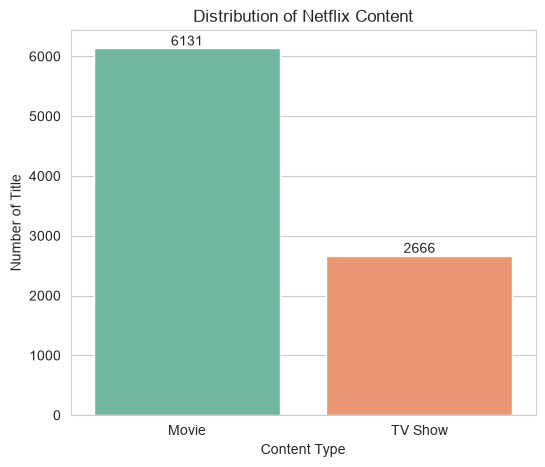

In [16]:
# Create a Bar Chart
plt.figure(figsize =(6,5))

ax = sns.countplot(
    data = df,
    x = "type",
    hue = "type",
    palette = "Set2",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Number of Title")

plt.show()

In [17]:
# Count title added each year
yearly_content = (
    df.groupby("year_added")["show_id"]
    .count()
    .reset_index(name = "total_title")
)

yearly_content.head()

,year_added,total_title
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3


In [18]:
# Find the year with the maximum title added
peak_year = yearly_content.loc[
    yearly_content["total_title"].idxmax()
]

print(peak_year)

year_added     2019
total_title    2016
Name: 11, dtype: int64


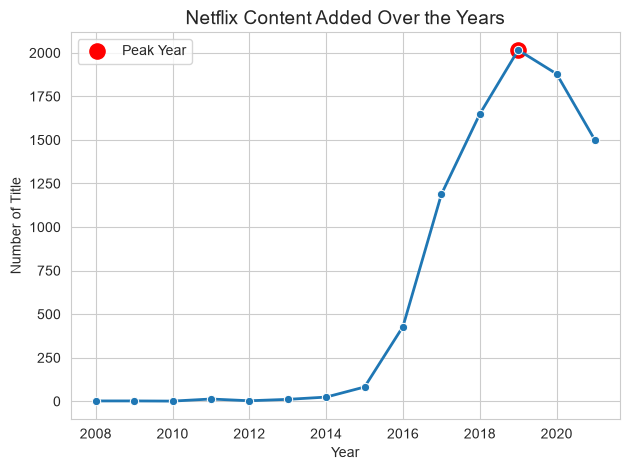

In [19]:
plt.Figure(figsize = (6,5))

ax = sns.lineplot(
    data = yearly_content,
    x = "year_added",
    y = "total_title",
    marker = "o",
    linewidth = 2
)

# Highlight the peak year
plt.scatter(
    peak_year["year_added"],
    peak_year["total_title"],
    s = 120,
    color = "red",
    label = "Peak Year"
)

plt.title("Netflix Content Added Over the Years", fontsize = 14)
plt.xlabel("Year")
plt.ylabel("Number of Title")

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
# Split multiple countries
country_df = df.copy()

country_df["country"] = country_df["country"].str.split(", ")

In [21]:
# Create one row for each country
country_df = country_df.explode("country")

In [22]:
top_countries = (
    country_df["country"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ["country", "total_title"]

top_countries

,country,total_title
0,United States,3683
1,India,1046
2,Unknown,830
3,United Kingdom,803
4,Canada,445
5,France,393
6,Japan,317
7,Spain,232
8,South Korea,231
9,Germany,226


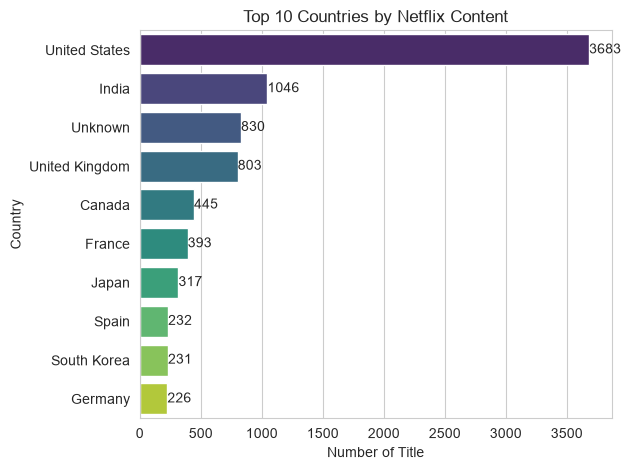

In [23]:
# Create a horizontal bar chart
plt.Figure(figsize = (10,6))

ax = sns.barplot(
    data = top_countries,
    x = "total_title",
    y = "country",
    hue = "country",
    palette = "viridis",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Title")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [24]:
# Create a copy for genre analysis
genre_df = df.copy()

In [25]:
# Convert genre into a list
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

# Create one row for each genre
genre_df = genre_df.explode("listed_in")

In [26]:
top_genre = (
    genre_df["listed_in"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_genre.columns = ["genre", "total_title"]

top_genre

,genre,total_title
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1350
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


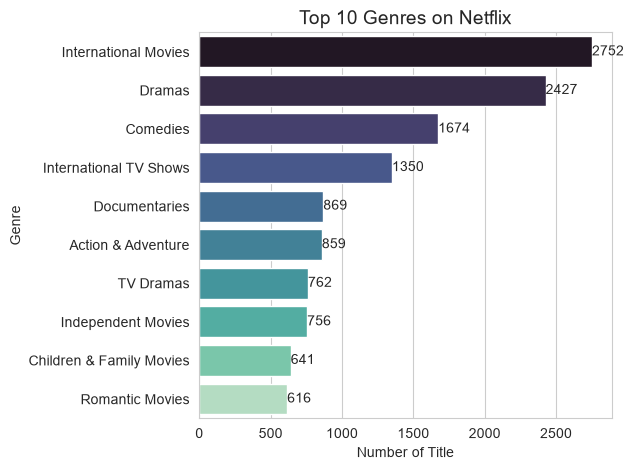

In [27]:
# Create the visualization
plt.Figure(figsize = (10,6))

ax = sns.barplot(
    data = top_genre,
    x = "total_title",
    y = "genre",
    hue = "genre",
    palette = "mako",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Genres on Netflix",fontsize = 14)
plt.xlabel("Number of Title")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [28]:
# Display unique rating
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str

In [29]:
rating_count = (
    df["rating"]
    .value_counts()
    .reset_index()
)

rating_count.columns = ["rating","total_title"]

rating_count

,rating,total_title
0,TV-MA,3209
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


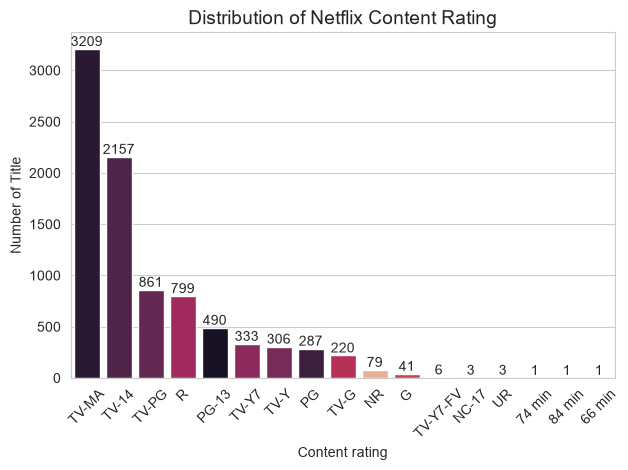

In [30]:
# plot the rating
plt.Figure(figsize = (12,6))

ax = sns.countplot(
    data = df,
    x = "rating",
    order = df["rating"].value_counts().index,
    hue = "rating",
    palette = "rocket",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Netflix Content Rating", fontsize = 14)
plt.xlabel("Content rating")
plt.ylabel("Number of Title")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [31]:
# Audience segmentation
audience_map = {
    "TV-Y": "Kids",
    "TV-Y7": "Kids",
    "TV-G": "Kids",
    "G": "Kids",
    
    "PG": "Family",
    "TV-PG": "Family",
    
    "PG-13": "Teen",
    "TV-14": "Teen",
    
    "R": "Adult",
    "TV-MA": "Adult",
    "NC-17": "Adult",
}

df["audience"] = df["rating"].map(audience_map)

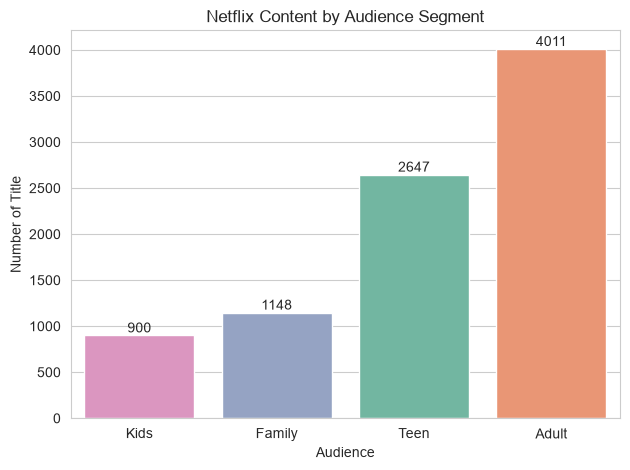

In [32]:
# Create a horizontal bar chart
plt.Figure(figsize = (8,5))

ax = sns.countplot(
    data = df,
    x = "audience",
    order = ["Kids", "Family","Teen", "Adult"],
    hue = "audience",
    palette = "Set2",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content by Audience Segment")
plt.xlabel("Audience")
plt.ylabel("Number of Title")

plt.tight_layout()
plt.show()

In [33]:
# Create a copy
director_df = df.copy()

In [34]:
# Remove unknown directors
director_df = director_df[director_df["director"] != "Unknown"]

In [35]:
# Split multiple directors
director_df["director"] = director_df["director"].str.split(", ")
print("\n", director_df["director"])


 0                     [Kirsten Johnson]
2                     [Julien Leclercq]
5                       [Mike Flanagan]
6       [Robert Cullen, José Luis Ucha]
7                        [Haile Gerima]
                     ...               
8801                  [Majid Al Ansari]
8802                    [David Fincher]
8804                  [Ruben Fleischer]
8805                     [Peter Hewitt]
8806                      [Mozez Singh]
Name: director, Length: 6173, dtype: object


In [36]:
# Explode the directors
director_df = director_df.explode("director")

In [37]:
top_directors = (
    director_df["director"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_directors.columns = ["director", "total_title"]

top_directors

,director,total_title
0,Rajiv Chilaka,22
1,Jan Suter,21
2,Raúl Campos,19
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,15
6,Cathy Garcia-Molina,13
7,Youssef Chahine,12
8,Martin Scorsese,12
9,Jay Chapman,12


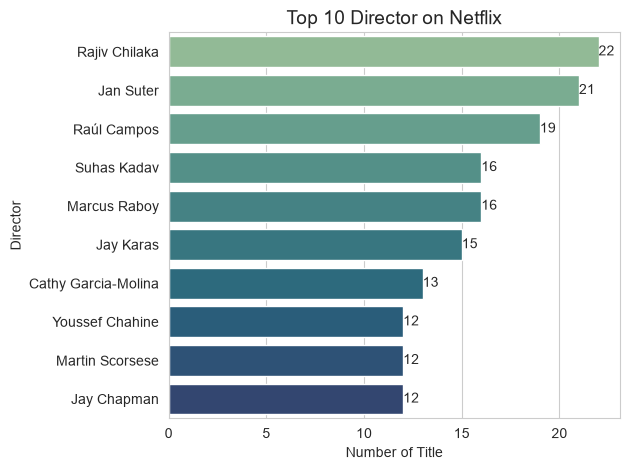

In [38]:
# Visualize the result
plt.Figure(figsize = (12,6))

ax = sns.barplot(
    data = top_directors,
    x = "total_title",
    y = "director",
    hue = "director",
    palette = "crest",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Director on Netflix", fontsize = 14)
plt.xlabel("Number of Title")
plt.ylabel("Director")

plt.tight_layout()
plt.show()

In [39]:
director_type = (
    director_df.groupby(["director", "type"])
    .size()
    .reset_index(name = "total_title")
)

director_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,day_added,content_age,decade,audience
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,25,1,2020,Teen
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,September,24,0,2020,Adult
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021,9,September,24,0,2020,Adult
6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,September,24,0,2020,Family
6,s7,Movie,My Little Pony: A New Generation,José Luis Ucha,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021,9,September,24,0,2020,Family


In [40]:
# Count title by release year
release_trend = (
    df.groupby("release_year")["show_id"]
    .count()
    .reset_index(name = "total_title")
)

release_trend.head()

,release_year,total_title
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


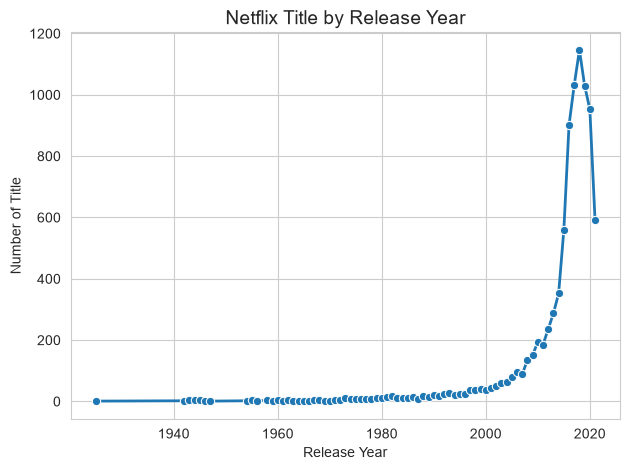

In [41]:
# Plot the release trend
plt.Figure(figsize = (12,6))

sns.lineplot(
    data = release_trend,
    x = "release_year",
    y = "total_title",
    linewidth = 2,
    marker = "o"
)

plt.title("Netflix Title by Release Year", fontsize = 14)
plt.xlabel("Release Year")
plt.ylabel("Number of Title")

plt.tight_layout()
plt.show()

In [42]:
# Compare movies vs tv shows
cocntent_trend = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name = "total_title")
)

cocntent_trend.head()

,release_year,type,total_title
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


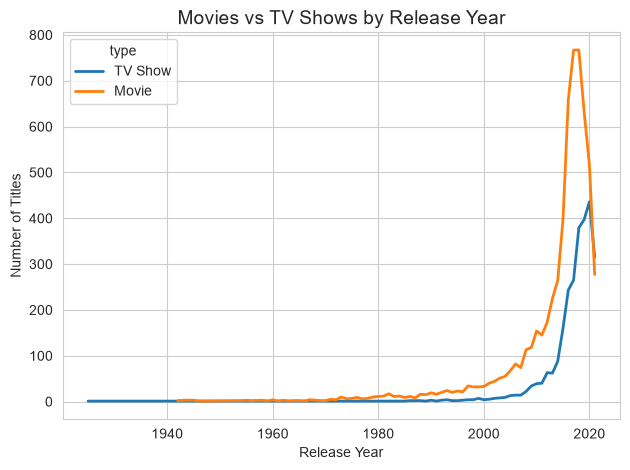

In [43]:
# Create a multi-line chart
plt.Figure(figsize = (14,6))

sns.lineplot(
    data = cocntent_trend,
    x = "release_year",
    y = "total_title",
    hue = "type",
    linewidth = 2
)

plt.title("Movies vs TV Shows by Release Year", fontsize = 14)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [44]:
# Identify the peak release year
peak_release = release_trend.loc[
    release_trend["total_title"].idxmax()
]

print(peak_release)

release_year    2018
total_title     1146
Name: 70, dtype: int64


In [45]:
# Content age Analysis
df["content_age"] = df["year_added"] - df["release_year"]

# Summary Statistics
df["content_age"].describe()

count    8797.000000
mean        4.688417
std         8.786998
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: content_age, dtype: float64

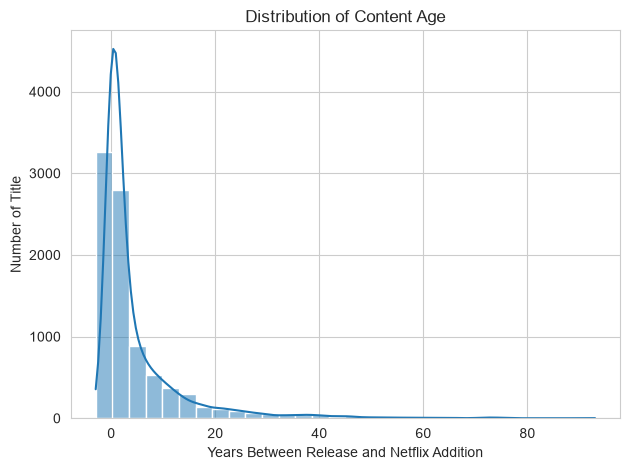

In [46]:
# Distribution of content age
plt.Figure(figsize = (10,6))

sns.histplot(
    data = df,
    x = "content_age",
    bins = 30,
    kde = True
)

plt.title("Distribution of Content Age")
plt.xlabel("Years Between Release and Netflix Addition")
plt.ylabel("Number of Title")

plt.tight_layout()
plt.show()

In [47]:
# Average Content Age By type
average_age = (
    df.groupby("type")["content_age"]
    .mean()
    .reset_index()
)

average_age

,type,content_age
0,Movie,5.727777
1,TV Show,2.298200


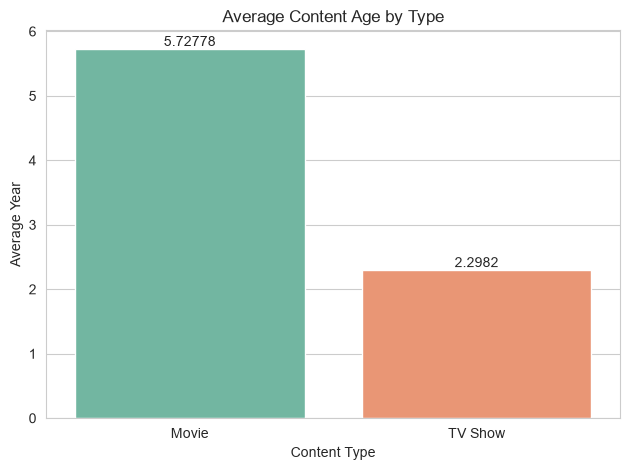

In [48]:
# Visualize the Comparison
plt.Figure(figsize = (6,5))

ax = sns.barplot(
    data = average_age,
    x = "type",
    y = "content_age",
    hue = "type",
    palette = "Set2",
    legend = False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Content Age by Type")
plt.xlabel("Content Type")
plt.ylabel("Average Year")

plt.tight_layout()
plt.show()

In [49]:
# Find recently added title
recent_title = [df["content_age"] == 0]

print("Title added in release year:",len(recent_title))

Title added in release year: 1


In [50]:
# Create a Working Dataframe
country_genre_df = df.copy()

country_genre_df["country"] = country_genre_df["country"].str.split(", ")

country_genre_df["listed_in"] = country_genre_df["listed_in"].str.split(", ")

country_genre_df = country_genre_df.explode("country")

country_genre_df = country_genre_df.explode("listed_in")

In [51]:
# Find the Top 5 Countries
top5_countries = (
    country_genre_df["country"]
    .value_counts()
    .head(5)
    .index
)

top5_countries

Index(['United States', 'India', 'United Kingdom', 'Unknown', 'France'], dtype='str', name='country')

In [52]:
# Filter the Dataset
filtered_df = country_genre_df[
country_genre_df["country"].isin(top5_countries)
]

In [53]:
# Count Genres by Country
country_genre = (
    filtered_df
    .groupby(["country", "listed_in"])
    .size()
    .reset_index(name = "total_title")
)

country_genre.head()

,country,listed_in,total_title
0,France,Action & Adventure,37
1,France,British TV Shows,2
2,France,Children & Family Movies,23
3,France,Classic Movies,6
4,France,Comedies,51


In [54]:
# Keep Top Genres Pre Country
country_genre = (
    country_genre
    .sort_values(["country", "total_title"],
    ascending = [True, False] 
    )
    .groupby("country")
    .head(5)
)

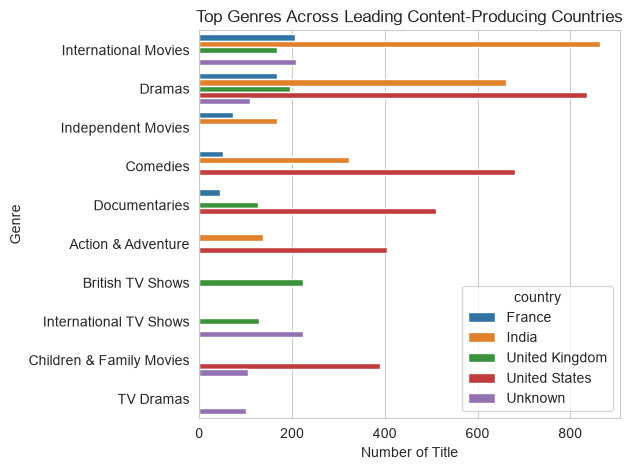

In [55]:
# Create the Visualization
plt.Figure(figsize = (14,7))

sns.barplot(
    data = country_genre,
    x = "total_title",
    y = "listed_in",
    hue = "country"
)

plt.title("Top Genres Across Leading Content-Producing Countries")
plt.xlabel("Number of Title")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()  

### KEY BUSINESS INSIGHTS

* Movies represent ~71% of the Netflix catalog.
* United States is the largest content contributor, followed by India.
* Content additions increased substantially after 2015.
* Movies and Documentaries are among the most represented genres.
* TV-MA is the most common content rating.